# CNN-Transformer-BiGRU v7 注意力机制可视化

本 Notebook 加载 v7 训练好的模型，可视化 Transformer 的注意力权重。
v7 模型架构：Post-Norm, d_model=128, nhead=4, num_encoder_layers=2, dropout=0.1

In [1]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import import_ipynb

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.5.1


---
## 第 1 步：加载模型和数据

In [2]:
from model_v7 import Improved_CNN_Transformer_BiGRU, ModelConfig

@dataclass
class TrainConfig:
    batch_size: int = 64
    seq_len: int = 168
    pred_len: int = 24
    input_dim: int = 53
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    checkpoint_path: str = "checkpoints/v7_model.pt"
    data_dir: str = "processed_data"

tconfig = TrainConfig()

mconfig = ModelConfig(
    input_dim=tconfig.input_dim,
    cnn_out_dim=32,
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    output_len=tconfig.pred_len
)

print(f"模型配置: {mconfig}")
print(f"训练配置: {tconfig}")

PyTorch version: 2.5.1
ModelConfig(input_dim=53, cnn_out_dim=32, d_model=128, nhead=4, num_encoder_layers=2, dim_feedforward=256, bigru_hidden=64, bigru_layers=1, output_len=24, dropout=0.1)
PositionalEncoding OK
MultiheadAttention OK
TransformerEncoderLayer (Post-Norm) OK
TransformerEncoder OK (layers=2)
EdgeDetectCNN OK
Model OK: torch.Size([4, 168, 53]) -> torch.Size([4, 24]), attn=2
总参数量: 359,896 (1.37 MB)
Baseline OK: params=46,680, full=359,896, diff=313,216
模型配置: ModelConfig(input_dim=53, cnn_out_dim=32, d_model=128, nhead=4, num_encoder_layers=2, dim_feedforward=256, bigru_hidden=64, bigru_layers=1, output_len=24, dropout=0.1)
训练配置: TrainConfig(batch_size=64, seq_len=168, pred_len=24, input_dim=53, device='cuda', checkpoint_path='checkpoints/v7_model.pt', data_dir='processed_data')


In [3]:
model = Improved_CNN_Transformer_BiGRU(mconfig)

if os.path.exists(tconfig.checkpoint_path):
    checkpoint = torch.load(tconfig.checkpoint_path, map_location=tconfig.device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\u2713 加载模型权重: {tconfig.checkpoint_path}")
else:
    print(f"\u26a0 未找到 checkpoint: {tconfig.checkpoint_path}")

model = model.to(tconfig.device)
model.eval()

test = np.load(os.path.join(tconfig.data_dir, 'test.npz'))
X_test = test['X']
y_test = test['y']

sample_idx = 0
x_sample = torch.FloatTensor(X_test[sample_idx:sample_idx+1]).to(tconfig.device)
y_sample = y_test[sample_idx]

with torch.no_grad():
    pred_sample, attn_list = model(x_sample)

print(f"\n样本索引: {sample_idx}")
print(f"输入 shape: {x_sample.shape}")
print(f"注意力层数: {len(attn_list)}")
print(f"每层注意力 shape: {[a.shape for a in attn_list]}")
print(f"预测输出 shape: {pred_sample.shape}")

✓ 加载模型权重: checkpoints/v7_model.pt

样本索引: 0
输入 shape: torch.Size([1, 168, 53])
注意力层数: 2
每层注意力 shape: [torch.Size([1, 4, 168, 168]), torch.Size([1, 4, 168, 168])]
预测输出 shape: torch.Size([1, 24])


---
## 第 2 步：注意力分布分析（判断是否摆烂）

In [4]:
def analyze_attention_distribution(attn_list):
    seq_len = attn_list[0].shape[-1]
    uniform_value = 1.0 / seq_len
    
    print("注意力分布分析")
    print("=" * 70)
    print(f"序列长度: {seq_len}, 均匀分布基准值: {uniform_value:.6f}")
    print("=" * 70)
    
    for layer_idx, attn in enumerate(attn_list):
        attn_np = attn[0].cpu().numpy()
        nhead = attn_np.shape[0]
        
        print(f"\nLayer {layer_idx + 1}:")
        print("-" * 50)
        
        for head_idx in range(nhead):
            head_attn = attn_np[head_idx]
            
            eps = 1e-9
            entropy = -np.sum(head_attn * np.log(head_attn + eps)) / head_attn.shape[0]
            
            threshold = uniform_value * 2
            sparsity = np.mean(head_attn > threshold)
            
            diag = np.diag(head_attn)
            diag_ratio = diag.mean() / head_attn.mean()
            
            max_val = head_attn.max()
            std_val = head_attn.std()
            
            print(f"  Head {head_idx + 1}: "
                  f"entropy={entropy:.3f}, "
                  f"sparsity={sparsity:.3f}, "
                  f"diag_ratio={diag_ratio:.2f}, "
                  f"max={max_val:.4f}, "
                  f"std={std_val:.4f}")
    
    print("\n=" * 70)
    print("判断标准:")
    print(f"  - 若 max 接近 {uniform_value:.4f} 且 std 很小 -> 注意力摆烂（均匀分布）")
    print(f"  - 若 entropy 高、sparsity 低 -> 注意力分散")
    print(f"  - 若 diag_ratio > 1.5 -> 模型关注局部时序模式")
    print("  - 若不同 head 的 pattern 差异大 -> 多头机制有效分工")
    print("=" * 70)

analyze_attention_distribution(attn_list)

注意力分布分析
序列长度: 168, 均匀分布基准值: 0.005952

Layer 1:
--------------------------------------------------
  Head 1: entropy=2.725, sparsity=0.053, diag_ratio=0.91, max=0.2952, std=0.0281
  Head 2: entropy=5.124, sparsity=0.000, diag_ratio=1.00, max=0.0060, std=0.0000
  Head 3: entropy=2.588, sparsity=0.063, diag_ratio=0.89, max=0.2408, std=0.0260
  Head 4: entropy=2.915, sparsity=0.070, diag_ratio=0.83, max=0.1781, std=0.0221

Layer 2:
--------------------------------------------------
  Head 1: entropy=5.124, sparsity=0.000, diag_ratio=1.00, max=0.0060, std=0.0000
  Head 2: entropy=5.124, sparsity=0.000, diag_ratio=1.00, max=0.0060, std=0.0000
  Head 3: entropy=5.124, sparsity=0.000, diag_ratio=1.00, max=0.0060, std=0.0000
  Head 4: entropy=5.124, sparsity=0.000, diag_ratio=1.00, max=0.0060, std=0.0000

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
判断标准:
  - 若 max 接近 0.0060 且 std 很小 -> 注意力摆烂（均匀分布）
  

---
## 第 3 步：可视化注意力热力图

=== Layer 1 注意力头可视化 ===


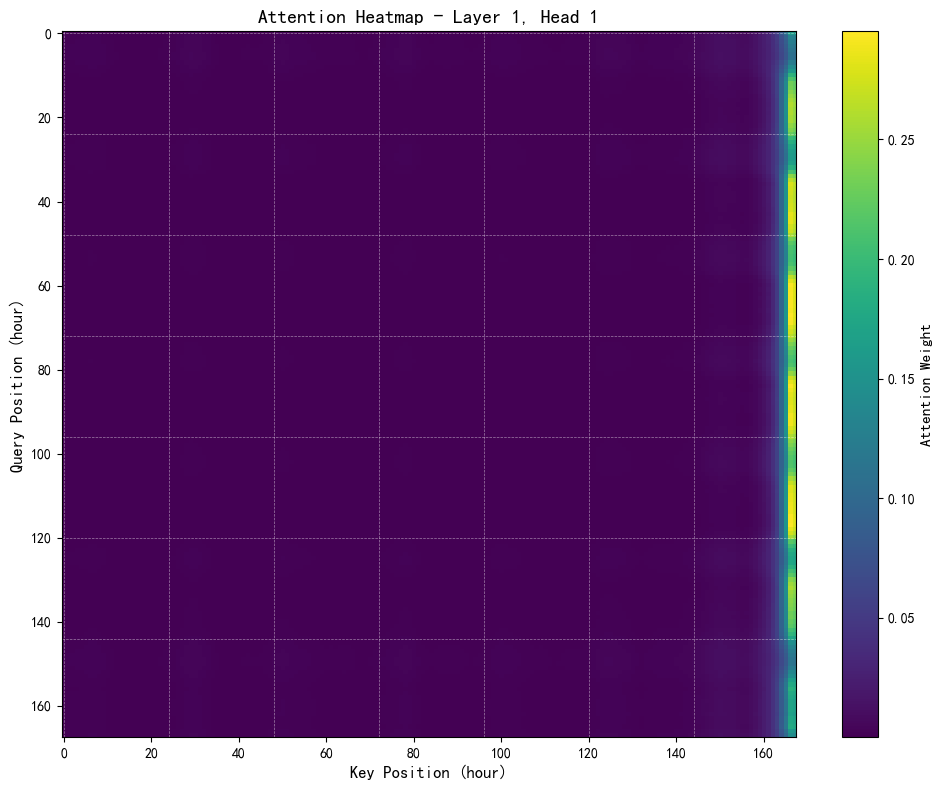

✓ 已保存: processed_data/visualization\v7_attention_layer1_head1.png


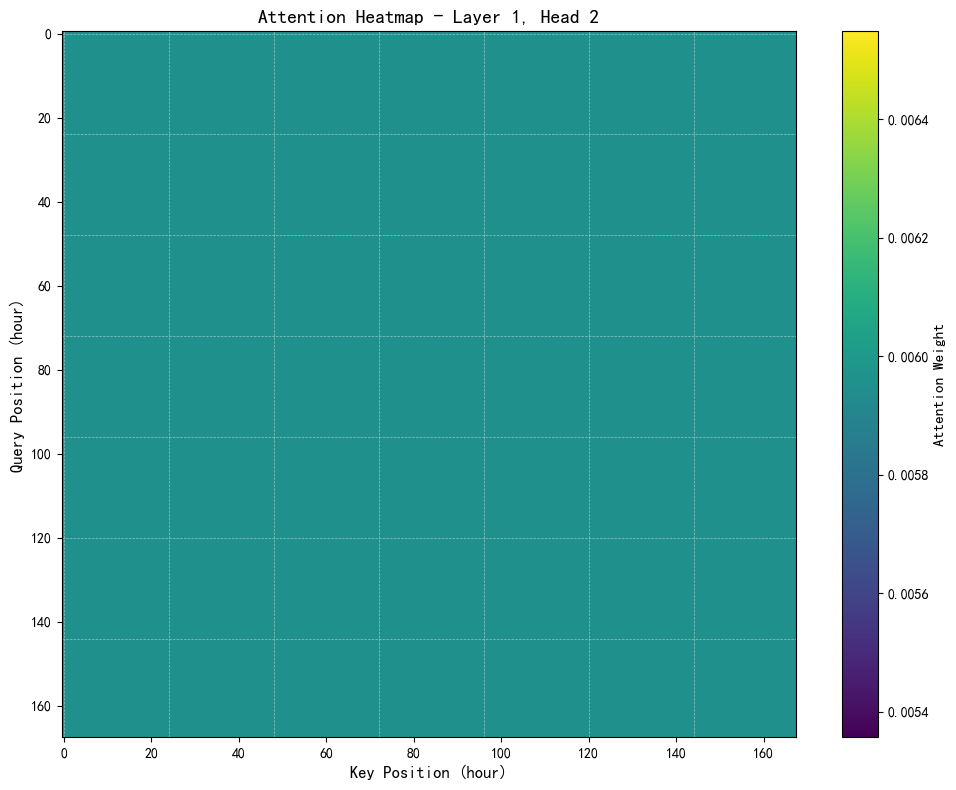

✓ 已保存: processed_data/visualization\v7_attention_layer1_head2.png


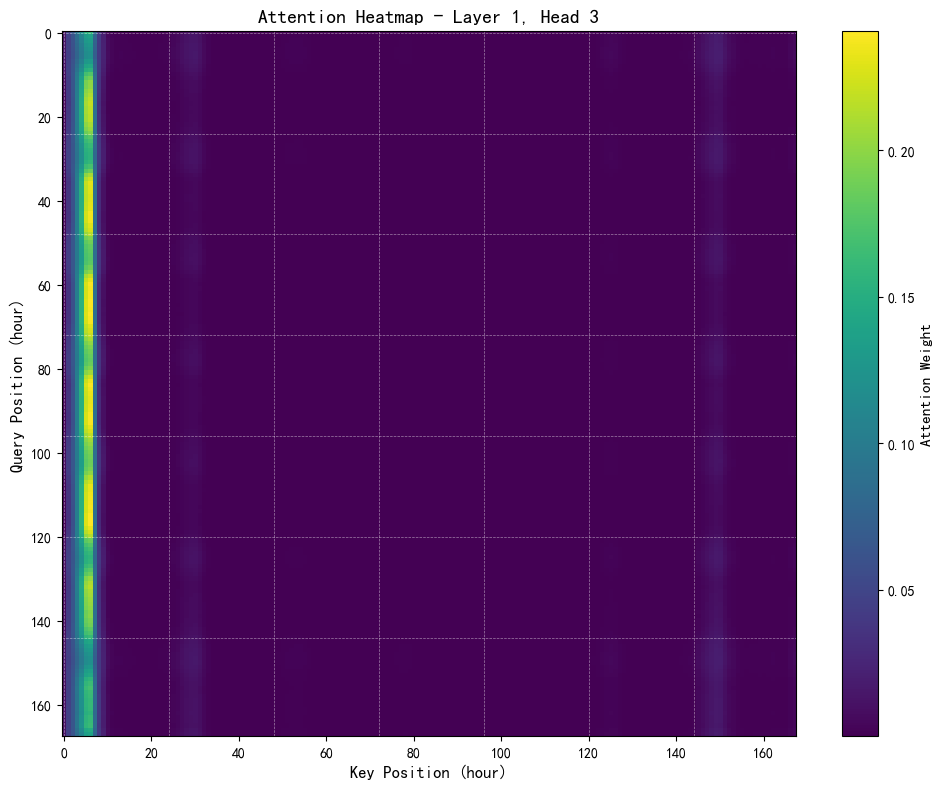

✓ 已保存: processed_data/visualization\v7_attention_layer1_head3.png


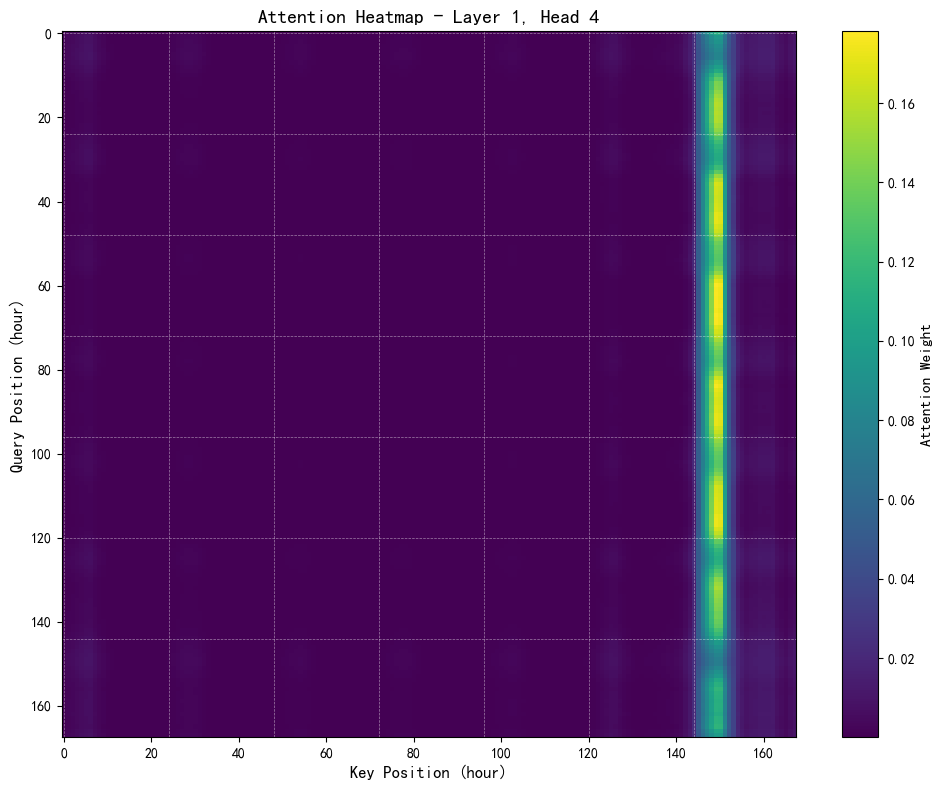

✓ 已保存: processed_data/visualization\v7_attention_layer1_head4.png


In [5]:
def plot_attention_heatmap(attn_weights, layer_idx, head_idx, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    attn = attn_weights[0, head_idx].cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn, cmap='viridis', aspect='auto')
    
    ax.set_xlabel('Key Position (hour)', fontsize=12)
    ax.set_ylabel('Query Position (hour)', fontsize=12)
    ax.set_title(f'Attention Heatmap - Layer {layer_idx+1}, Head {head_idx+1}', 
                 fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attention Weight', fontsize=11)
    
    for h in range(0, attn.shape[0], 24):
        ax.axvline(x=h, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.axhline(y=h, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, f'v7_attention_layer{layer_idx+1}_head{head_idx+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 已保存: {save_path}")
    return fig

print("=== Layer 1 注意力头可视化 ===")
for head in range(mconfig.nhead):
    plot_attention_heatmap(attn_list[0], layer_idx=0, head_idx=head)

=== Layer 2 注意力头可视化 ===


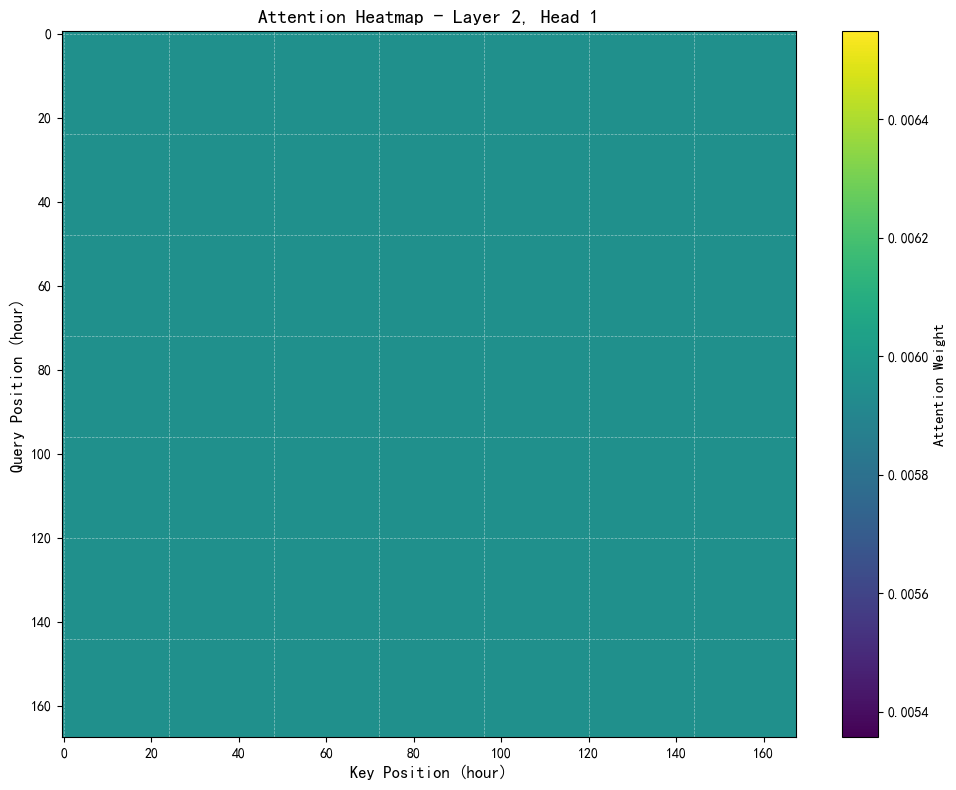

✓ 已保存: processed_data/visualization\v7_attention_layer2_head1.png


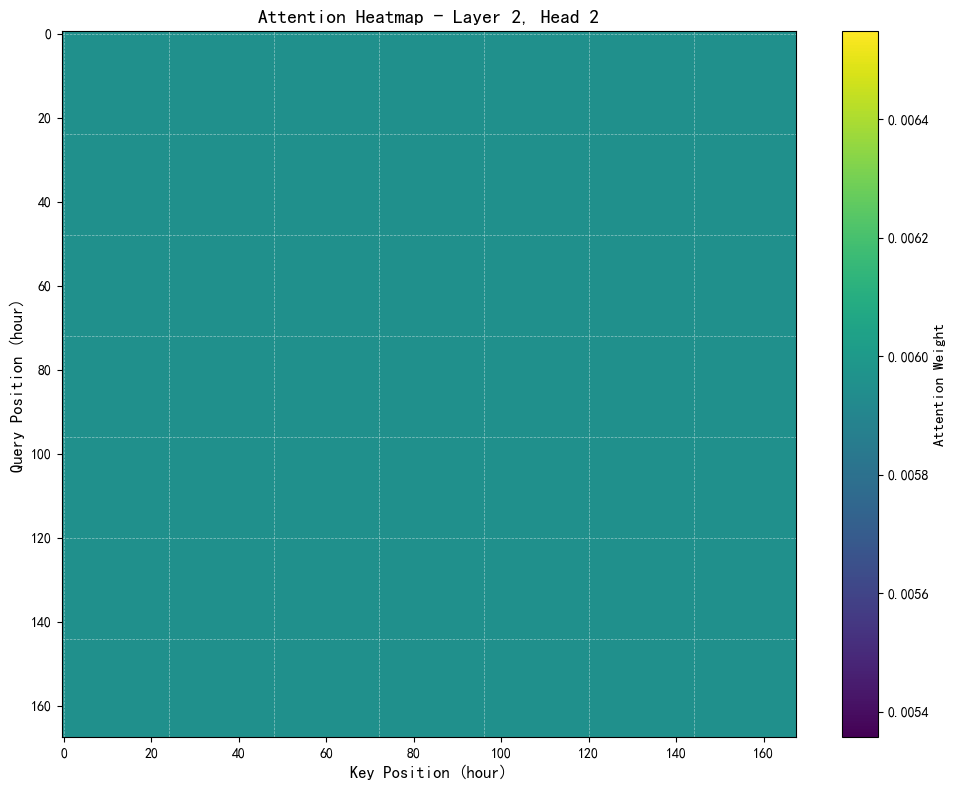

✓ 已保存: processed_data/visualization\v7_attention_layer2_head2.png


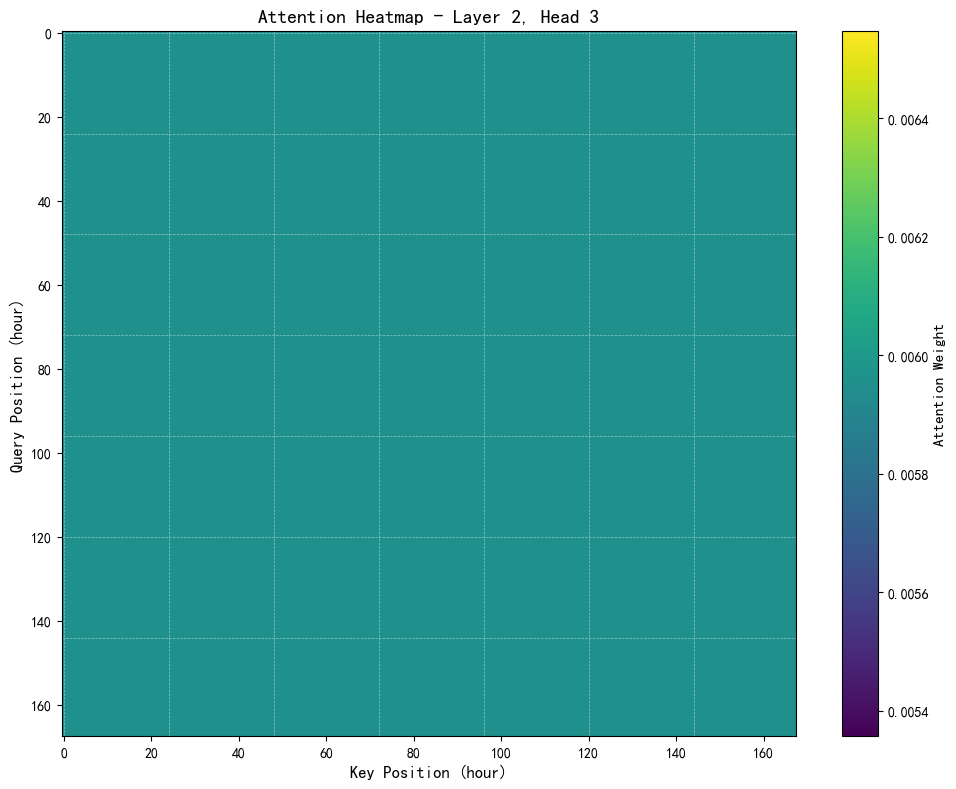

✓ 已保存: processed_data/visualization\v7_attention_layer2_head3.png


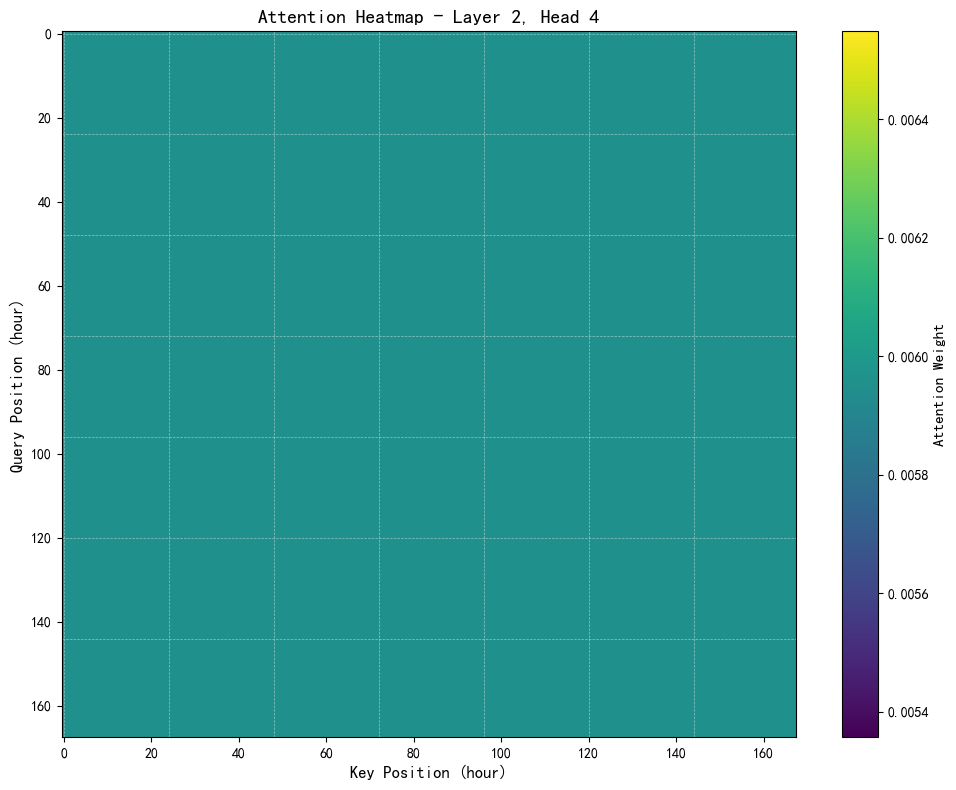

✓ 已保存: processed_data/visualization\v7_attention_layer2_head4.png


In [6]:
print("=== Layer 2 注意力头可视化 ===")
for head in range(mconfig.nhead):
    plot_attention_heatmap(attn_list[1], layer_idx=1, head_idx=head)

---
## 第 4 步：多层注意力对比

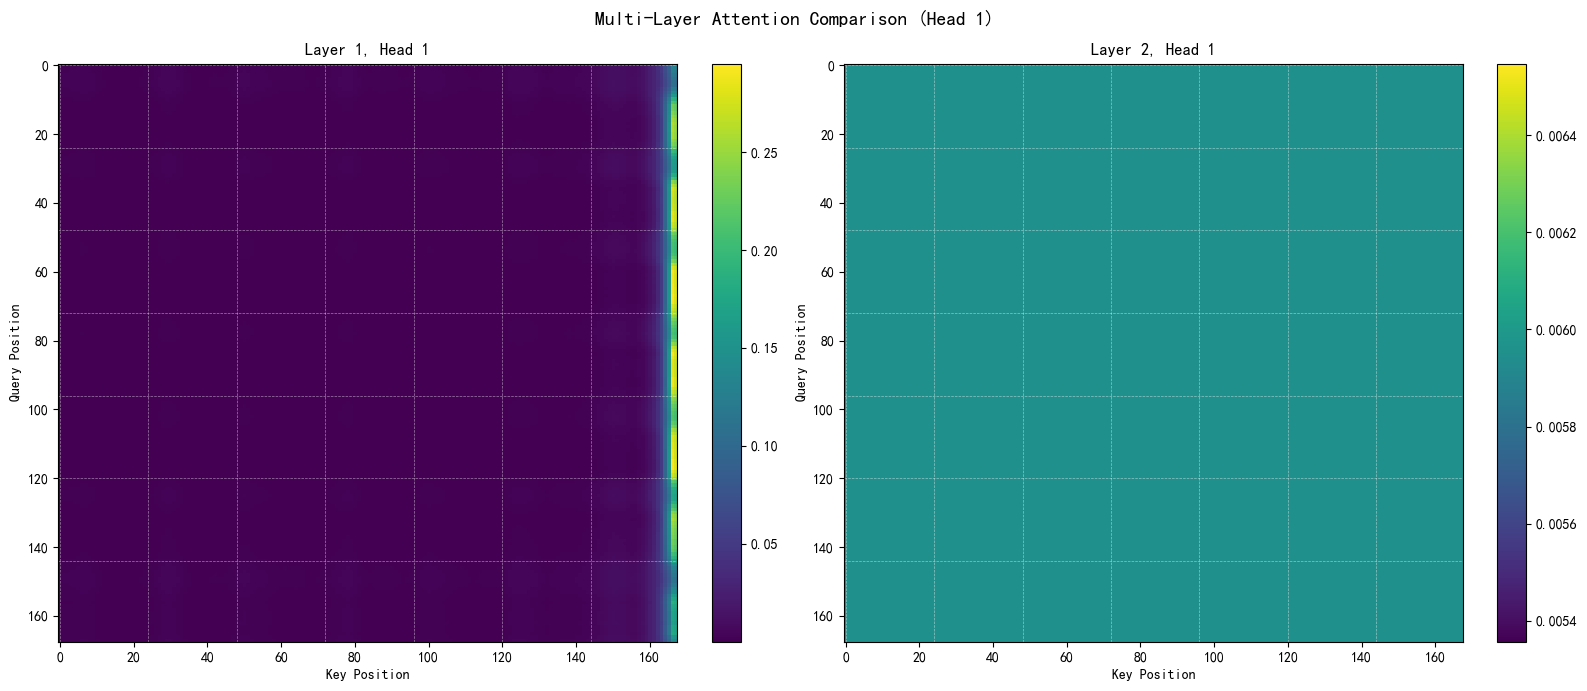

✓ 已保存: processed_data/visualization\v7_multi_layer_attention_head1.png


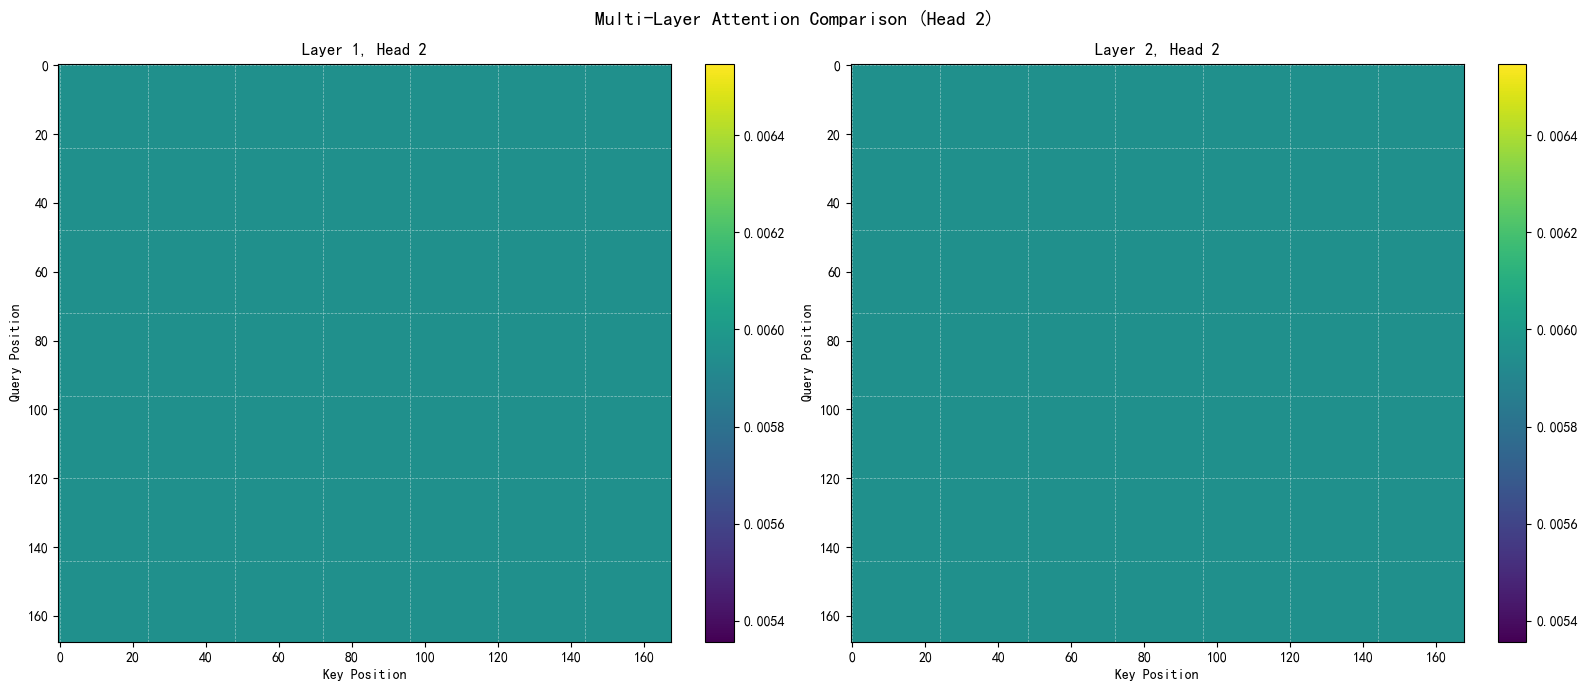

✓ 已保存: processed_data/visualization\v7_multi_layer_attention_head2.png


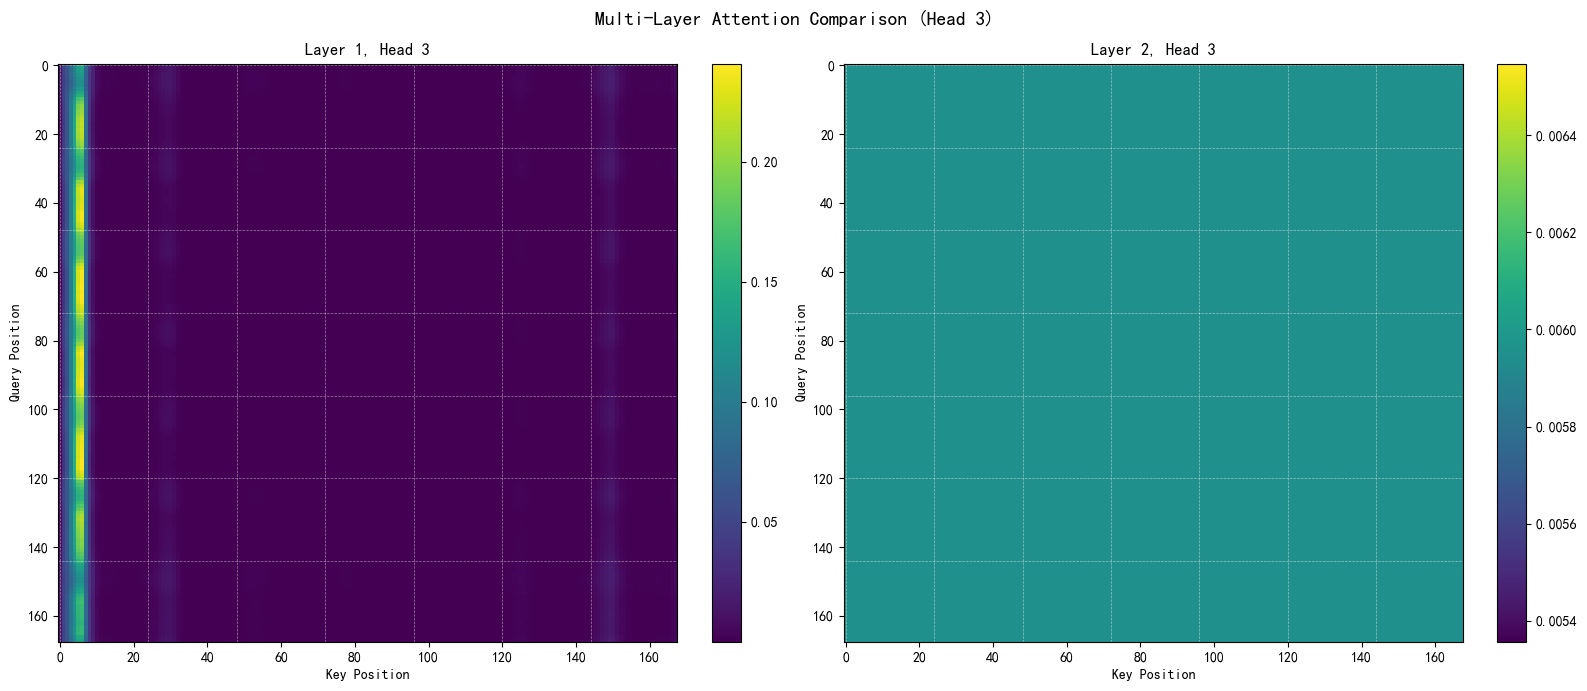

✓ 已保存: processed_data/visualization\v7_multi_layer_attention_head3.png


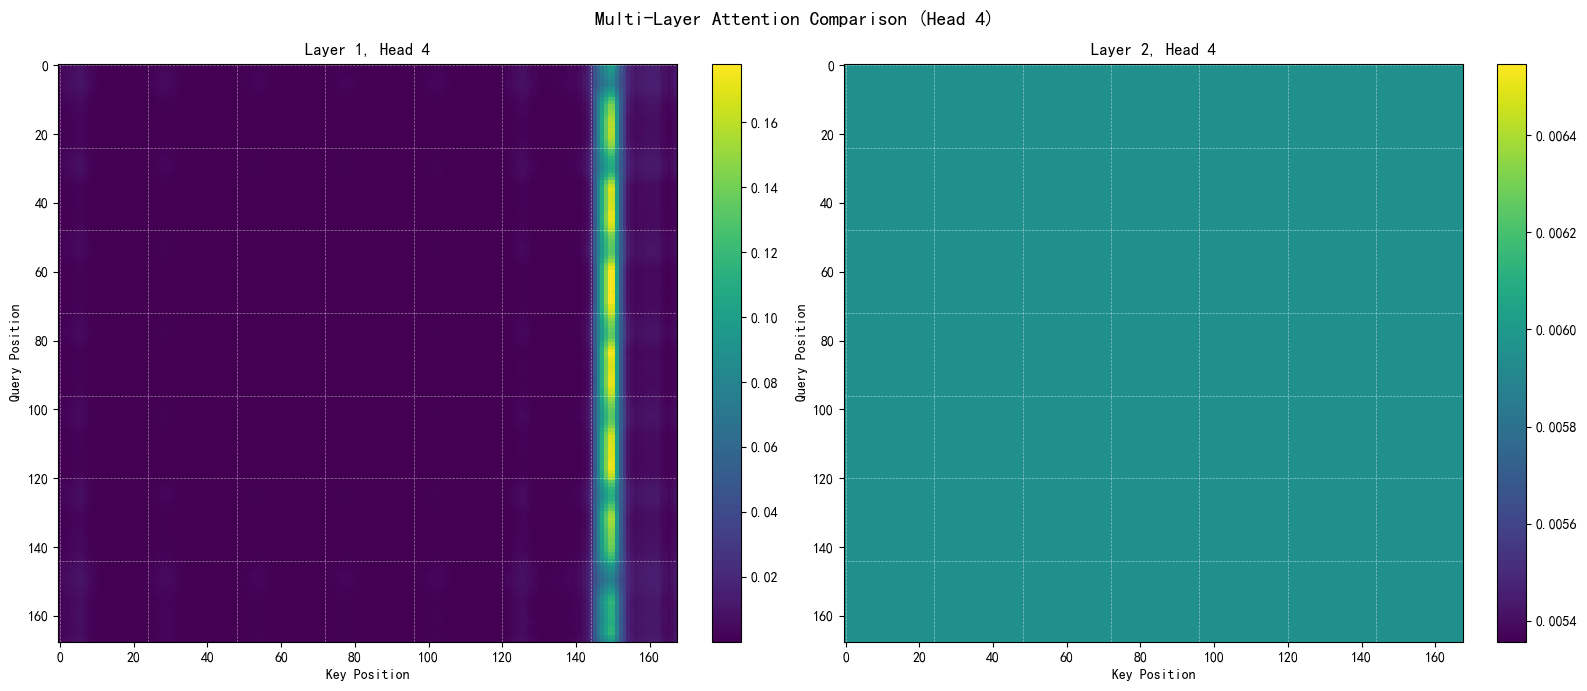

✓ 已保存: processed_data/visualization\v7_multi_layer_attention_head4.png


In [7]:
def plot_multi_layer_attention(attn_list, head_idx=0, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    n_layers = len(attn_list)
    nhead = attn_list[0].shape[1]
    
    if n_layers == 2:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    else:
        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    if n_layers == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else axes
    
    for layer_idx in range(n_layers):
        attn = attn_list[layer_idx][0, head_idx].cpu().numpy()
        ax = axes[layer_idx] if n_layers > 1 else axes[0]
        im = ax.imshow(attn, cmap='viridis', aspect='auto')
        ax.set_title(f'Layer {layer_idx+1}, Head {head_idx+1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Key Position', fontsize=10)
        ax.set_ylabel('Query Position', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046)
        
        for h in range(0, attn.shape[0], 24):
            ax.axvline(x=h, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
            ax.axhline(y=h, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
    
    plt.suptitle(f'Multi-Layer Attention Comparison (Head {head_idx+1})', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, f'v7_multi_layer_attention_head{head_idx+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 已保存: {save_path}")
    return fig

for head in range(mconfig.nhead):
    plot_multi_layer_attention(attn_list, head_idx=head)

---
## 第 5 步：注意力头差异分析

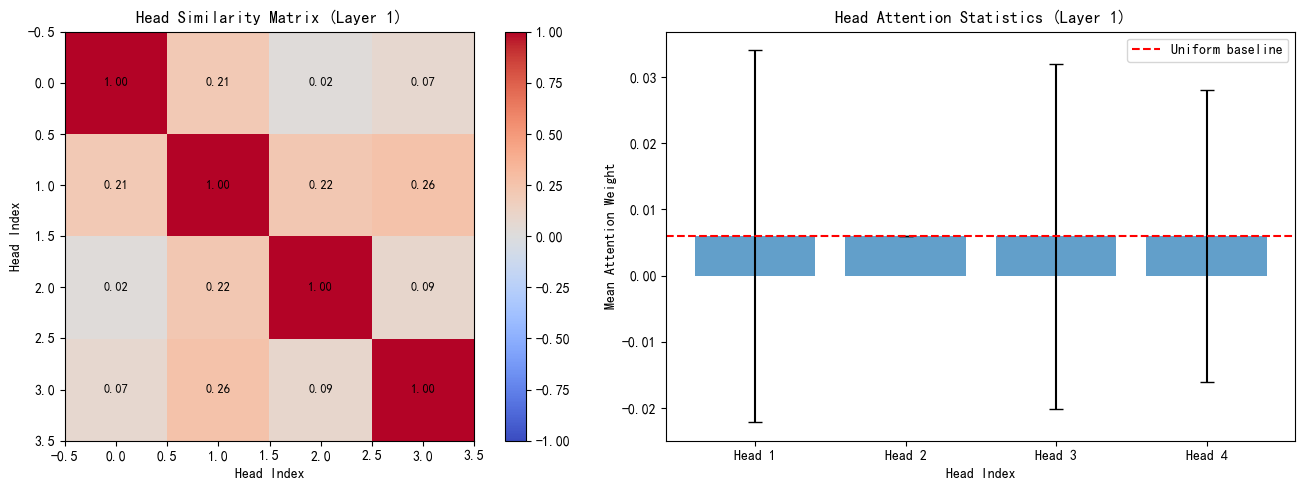

✓ 已保存: processed_data/visualization\v7_head_diversity_layer1.png

Layer 1 Head 相似度统计:
  平均相似度: 0.1449
  相似度范围: [0.0168, 0.2606]
  ✓ Head 之间差异明显，多头机制有效


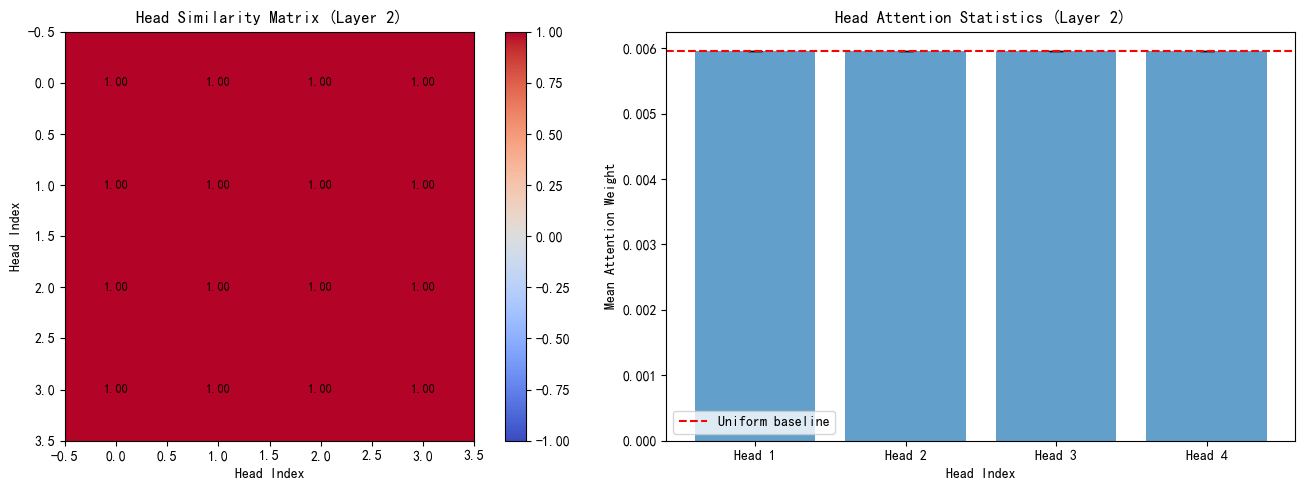

✓ 已保存: processed_data/visualization\v7_head_diversity_layer2.png

Layer 2 Head 相似度统计:
  平均相似度: 1.0000
  相似度范围: [1.0000, 1.0000]
  ⚠ 警告: Head 之间过于相似，多头机制可能未有效分工


In [8]:
def plot_head_diversity(attn_list, layer_idx=0, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    attn = attn_list[layer_idx][0].cpu().numpy()
    nhead = attn.shape[0]
    
    from sklearn.metrics.pairwise import cosine_similarity
    
    attn_flat = attn.reshape(nhead, -1)
    similarity = cosine_similarity(attn_flat)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im1 = axes[0].imshow(similarity, cmap='coolwarm', vmin=-1, vmax=1)
    axes[0].set_title(f'Head Similarity Matrix (Layer {layer_idx+1})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Head Index')
    axes[0].set_ylabel('Head Index')
    for i in range(nhead):
        for j in range(nhead):
            axes[0].text(j, i, f'{similarity[i, j]:.2f}', 
                        ha='center', va='center', fontsize=9)
    plt.colorbar(im1, ax=axes[0])
    
    head_means = attn.mean(axis=(1, 2))
    head_stds = attn.std(axis=(1, 2))
    x_pos = np.arange(nhead)
    axes[1].bar(x_pos, head_means, yerr=head_stds, capsize=5, alpha=0.7)
    axes[1].set_title(f'Head Attention Statistics (Layer {layer_idx+1})', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Head Index')
    axes[1].set_ylabel('Mean Attention Weight')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([f'Head {i+1}' for i in range(nhead)])
    axes[1].axhline(y=1.0/attn.shape[-1], color='r', linestyle='--', 
                    label='Uniform baseline')
    axes[1].legend()
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, f'v7_head_diversity_layer{layer_idx+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 已保存: {save_path}")
    
    triu_idx = np.triu_indices(nhead, k=1)
    triu_sim = similarity[triu_idx]
    print(f"\nLayer {layer_idx+1} Head 相似度统计:")
    print(f"  平均相似度: {triu_sim.mean():.4f}")
    print(f"  相似度范围: [{triu_sim.min():.4f}, {triu_sim.max():.4f}]")
    if triu_sim.mean() > 0.9:
        print(f"  \u26a0 警告: Head 之间过于相似，多头机制可能未有效分工")
    else:
        print(f"  \u2713 Head 之间差异明显，多头机制有效")
    
    return fig

for layer in range(len(attn_list)):
    plot_head_diversity(attn_list, layer_idx=layer)

---
## 第 6 步：注意力统计摘要

In [9]:
print("注意力权重统计摘要")
print("="*60)
for layer_idx, attn in enumerate(attn_list):
    attn_np = attn[0].cpu().numpy()
    print(f"\nLayer {layer_idx+1}:")
    print(f"  形状: {attn_np.shape}")
    print(f"  均值: {attn_np.mean():.6f}")
    print(f"  标准差: {attn_np.std():.6f}")
    print(f"  最大值: {attn_np.max():.6f}")
    print(f"  最小值: {attn_np.min():.6f}")
    
    for head_idx in range(attn_np.shape[0]):
        head_attn = attn_np[head_idx]
        diag_mean = np.diag(head_attn).mean()
        print(f"    Head {head_idx+1}: diag_mean={diag_mean:.6f}, max={head_attn.max():.4f}, std={head_attn.std():.4f}")

print("\n="*60)
print("\u2713 注意力可视化完成！")

注意力权重统计摘要

Layer 1:
  形状: (4, 168, 168)
  均值: 0.005952
  标准差: 0.022087
  最大值: 0.295163
  最小值: 0.000000
    Head 1: diag_mean=0.005396, max=0.2952, std=0.0281
    Head 2: diag_mean=0.005952, max=0.0060, std=0.0000
    Head 3: diag_mean=0.005277, max=0.2408, std=0.0260
    Head 4: diag_mean=0.004968, max=0.1781, std=0.0221

Layer 2:
  形状: (4, 168, 168)
  均值: 0.005952
  标准差: 0.000000
  最大值: 0.005952
  最小值: 0.005952
    Head 1: diag_mean=0.005952, max=0.0060, std=0.0000
    Head 2: diag_mean=0.005952, max=0.0060, std=0.0000
    Head 3: diag_mean=0.005952, max=0.0060, std=0.0000
    Head 4: diag_mean=0.005952, max=0.0060, std=0.0000

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
✓ 注意力可视化完成！


---
## 输出文件清单

| 文件名 | 说明 |
|:---|:---|
| `v7_attention_layer1_head1.png` ~ `head4.png` | 第1层各注意力头热力图 |
| `v7_attention_layer2_head1.png` ~ `head4.png` | 第2层各注意力头热力图 |
| `v7_multi_layer_attention_head1.png` ~ `head4.png` | 各 head 跨层对比图 |
| `v7_head_diversity_layer1.png` / `layer2.png` | 注意力头差异分析图 |